# Attack Classification Head

In [133]:
!cp ./drive/MyDrive/DATA/Capstone-dataset/* .

In [134]:
! pip install xgboost

In [135]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [136]:
df = pd.read_csv("./attack_classification.csv")
df.head()

,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18883,80,1293792,3,7,26,11607,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
1,18884,80,4421382,4,0,24,0,6,6,6.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
2,18885,80,1083538,3,6,26,11601,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS
3,18886,80,80034360,8,4,56,11601,20,0,7.000000,...,20,939.0,0.0,939,939,39300000.0,44200000.0,70600000,8072664,DDoS
4,18887,80,642654,3,6,26,11607,20,0,8.666667,...,20,0.0,0.0,0,0,0.0,0.0,0,0,DDoS


In [137]:
for c in df.columns:
  if not df[c].dtype in ['int64', 'float64']:
    print(c, end=', ')


Label, 

In [138]:
X = df.drop(columns=['Label'])
y = df['Label']

x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [139]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [143]:
x_train = x_train.replace([np.inf, -np.inf], np.nan)
x_test = x_test.replace([np.inf, -np.inf], np.nan)

In [144]:
import numpy as np

model = xgb.XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100
)
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [145]:
y_pred = model.predict(x_test)

In [151]:
y_pred_labels = encoder.inverse_transform(y_pred)
y_test_labels = encoder.inverse_transform(y_test)

In [152]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:\n", classification_rep)

Accuracy: 0.9999701499220167
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     31898
           1       1.00      1.00      1.00     57857
           2       1.00      1.00      1.00     39724
           3       1.00      1.00      1.00      4524

    accuracy                           1.00    134003
   macro avg       1.00      1.00      1.00    134003
weighted avg       1.00      1.00      1.00    134003



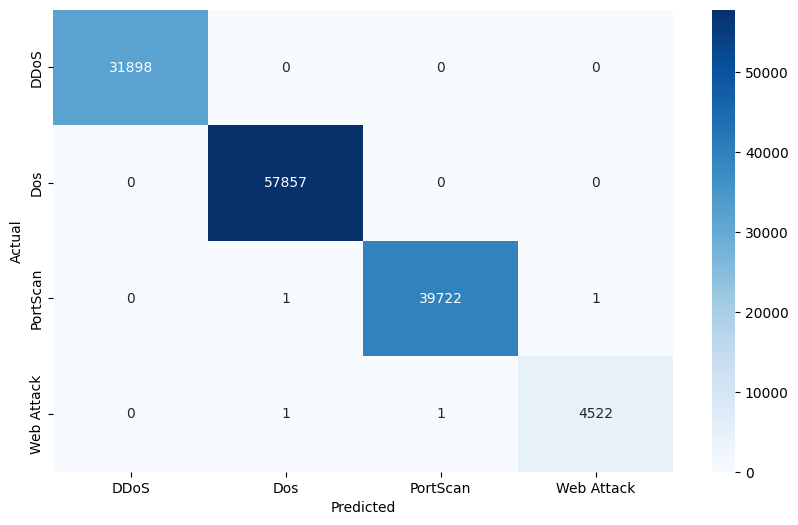

In [153]:
from sklearn.metrics import confusion_matrix,precision_recall_curve, average_precision_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confussion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
def plot_pr_curve(y_true, y_scores):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)

    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (AP={ap:.3f})")
    plt.grid()
    plt.show()
def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
    plt.grid()
    plt.show()
plot_confussion_matrix(y_test, y_pred)

In [154]:
import joblib

joblib.dump(model, "classifier.pkl")

['classifier.pkl']